<a href="https://colab.research.google.com/github/talgiladi/Portfolio/blob/main/Training_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,),(0.5,))]
)

training_set = torchvision.datasets.FashionMNIST('./data', train = True, transform = transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train = False, transform = transform, download = True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size = 4, shuffle = True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size = 4, shuffle = False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Report split sizes
print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.70MB/s]

Training set has 60000 instances
Validation set has 10000 instances


Bag|Pullover|Bag|Trouser


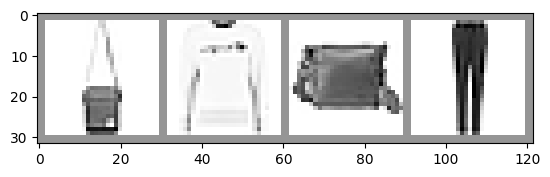

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def matplotlib_imshow(img, one_channel = True):
  if one_channel:
    img = img.mean(dim = 0)
  img = img / 2 + 0.5
  npimg = img.numpy()
  if one_channel:
    plt.imshow(npimg, cmap = "Greys")
  else:
    plt.imshow(np.transpose(npimg, (1,2,0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel = True)
print('|'.join(classes[labels[j]] for j in range(4)))


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class GarmentClassifier(nn.Module):
  def __init__(self):
    super(GarmentClassifier, self).__init__()
    self.conv1 = nn.Conv2d(1, 6, 5) #in 28*28, out 28-5+1 = 24*24 * 6. after max pool 24 / 2 = 12 * 12 * 6
    self.conv2 = nn.Conv2d(6, 16, 5) #in 12*12, out 12 - 5 + 1 = 8. after max pool = 4 * 4 * 16
    self.max_pool = nn.MaxPool2d(2,2)
    self.fc1 = nn.Linear(16 * 4 * 4, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x) -> torch.Tensor:
    x = self.max_pool(F.relu(self.conv1(x)))
    x = self.max_pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 4 * 4)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

model = GarmentClassifier()

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001, momentum = 0.9)

In [12]:
def train_one_epoch(epoch_index, tb_writer):
  running_loss = 0
  last_loss = 0

  for i, data in enumerate(training_loader):
    inputs, labels = data
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, target = labels)

    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    if (i%1000 == 999):
      last_loss = running_loss / 1000
      print(f"Batch #{i+1}, loss {last_loss}")
      tb_x = epoch_index * len(training_loader) + i + 1
      tb_writer.add_scalar('Loss/train', last_loss, tb_x)
      running_loss = 0

  return last_loss

In [13]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
writer = SummaryWriter(f'runs/fashion_trainer_{timestamp}')

epoch_number = 0
EPOCHS = 5

best_vloss = 1_000_000

for epoch in range(EPOCHS):
  print(f"Epoch #{epoch_number + 1}")
  model.train(True)
  avg_loss = train_one_epoch(epoch_number, writer)

  running_vloss = 0.0

  model.eval()

  with torch.no_grad():
    for i, vdata in enumerate(validation_loader):
      vinputs, vlabels = vdata
      voutputs = model(vinputs)
      vloss = loss_fn(voutputs, vlabels)
      running_vloss +=vloss

  avg_vloss = running_vloss / (i+1)

  print(f"Loss train {avg_loss} validation {avg_vloss}")

  writer.add_scalars("Training vs Validation Loss", {"Training": avg_loss, "Validation" : avg_vloss}, epoch_number + 1)

  writer.flush()

  if avg_vloss < best_vloss:
    best_vloss = avg_vloss
    model_path = f"model_{timestamp}_{epoch_number}"
    torch.save(model.state_dict(), model_path)

  epoch_number +=1

Epoch #1
Batch #1000, loss 0.39160668189346326
Batch #2000, loss 0.3962021535829408
Batch #3000, loss 0.3909668293495197
Batch #4000, loss 0.38315371121000497
Batch #5000, loss 0.37696424476371615
Batch #6000, loss 0.3847303024440771
Batch #7000, loss 0.37014339871944685
Batch #8000, loss 0.382927439727413
Batch #9000, loss 0.370376502148225
Batch #10000, loss 0.3424504459503514
Batch #11000, loss 0.3595524940227624
Batch #12000, loss 0.34506057221395897
Batch #13000, loss 0.36188490929602996
Batch #14000, loss 0.33748598877346375
Batch #15000, loss 0.33620546054175066
Loss train 0.33620546054175066 validation 0.3727973699569702
Epoch #2
Batch #1000, loss 0.3212677171542018
Batch #2000, loss 0.346845467947569
Batch #3000, loss 0.3232834301631374
Batch #4000, loss 0.34865585220890355
Batch #5000, loss 0.3088720716637254
Batch #6000, loss 0.31623031030019044
Batch #7000, loss 0.3265802030910709
Batch #8000, loss 0.3215590940579495
Batch #9000, loss 0.31874993162561444
Batch #10000, loss 

In [ ]:
# PATH = ""

# saved_model = GarmentClassifier()

# saved_model.load_state_dict(torch.load(PATH))